<a href="https://colab.research.google.com/github/pplateena/AIIIT-NULP/blob/main/l2/torch_models_ran.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Neural Networks Implementation - Lab 1
## Tasks 5-10: Neural Network Training and Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pplateena/AIIIT-NULP/l2/blob/main/torch_models.ipynb)

This notebook implements PyTorch neural networks for the Titanic survival prediction task, covering:
- **Task 5**: Data splitting (train/validation/test)
- **Task 6**: Basic and advanced neural network architectures
- **Task 7**: Activation function comparison (ReLU, LeakyReLU, GELU)
- **Task 8**: Model training with callbacks
- **Task 9**: Comprehensive evaluation metrics
- **Task 10**: Training curves and visualization analysis

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/transformed_df.csv'
df_final = pd.read_csv(drive_path)
print(f"✅ Dataset loaded from Google Drive: {df_final.shape}")


if df_final is not None:
    print(f"\n📋 Dataset Info:")
    print(f"   Shape: {df_final.shape}")
    print(f"   Columns: {list(df_final.columns)}")
    print(f"   Target distribution: {df_final['Survived'].value_counts().to_dict()}")
else:
    print("⚠️ Dataset not loaded. Please fix the data source before continuing.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset loaded from Google Drive: (891, 14)

📋 Dataset Info:
   Shape: (891, 14)
   Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'IsAlone', 'AgeCategory', 'FareCategory']
   Target distribution: {0: 549, 1: 342}


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score
import warnings
warnings.filterwarnings('ignore')

print("PyTorch version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))
    print("CUDA device count:", torch.cuda.device_count())

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.8.0+cu126
CUDA Available: True
CUDA device: Tesla T4
CUDA device count: 1
Using device: cuda


In [5]:
# TASK 5: Train/Validation/Test Split
print("="*60)
print("TASK 5: TRAIN/VALIDATION/TEST SPLIT")
print("="*60)

# Prepare features and target
X = df_final.drop('Survived', axis=1).values
y = df_final['Survived'].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution: {np.bincount(y)} (0: died, 1: survived)")

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 60% train, 20% validation (from the 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp  # 0.25 * 0.8 = 0.2
)

print(f"\nSplit results:")
print(f"Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Check class distribution in each split
train_dist = np.bincount(y_train)
val_dist = np.bincount(y_val)
test_dist = np.bincount(y_test)

print(f"\nClass distribution:")
print(f"Train: {train_dist} ({train_dist[1]/len(y_train)*100:.1f}% survived)")
print(f"Val:   {val_dist} ({val_dist[1]/len(y_val)*100:.1f}% survived)")
print(f"Test:  {test_dist} ({test_dist[1]/len(y_test)*100:.1f}% survived)")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

print(f"\nPyTorch tensors created:")
print(f"X_train_tensor: {X_train_tensor.shape}, dtype: {X_train_tensor.dtype}, device: {X_train_tensor.device}")
print(f"y_train_tensor: {y_train_tensor.shape}, dtype: {y_train_tensor.dtype}, device: {y_train_tensor.device}")

# Create DataLoaders
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataLoaders created with batch size: {batch_size}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

print("✅ Task 5 completed: Train/Validation/Test split ready")

TASK 5: TRAIN/VALIDATION/TEST SPLIT
Features shape: (891, 13)
Target shape: (891,)
Target distribution: [549 342] (0: died, 1: survived)

Split results:
Train set: 534 samples (59.9%)
Validation set: 178 samples (20.0%)
Test set: 179 samples (20.1%)

Class distribution:
Train: [329 205] (38.4% survived)
Val:   [110  68] (38.2% survived)
Test:  [110  69] (38.5% survived)

PyTorch tensors created:
X_train_tensor: torch.Size([534, 13]), dtype: torch.float32, device: cuda:0
y_train_tensor: torch.Size([534]), dtype: torch.float32, device: cuda:0

DataLoaders created with batch size: 32
Train batches: 17
Val batches: 6
Test batches: 6
✅ Task 5 completed: Train/Validation/Test split ready


In [6]:
# TASK 6A: Basic Feedforward Neural Network
print("="*60)
print("TASK 6A: BASIC FEEDFORWARD NEURAL NETWORK")
print("="*60)

class BasicNet(nn.Module):
    """
    Basic feedforward neural network with minimum 2 hidden layers
    """
    def __init__(self, input_dim, activation='relu'):
        super(BasicNet, self).__init__()

        # Define layers
        self.hidden1 = nn.Linear(input_dim, 128)
        self.hidden2 = nn.Linear(128, 64)
        self.hidden3 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)

        # Set activation function
        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'leaky_relu':
            self.activation = nn.LeakyReLU(0.2)
        elif activation == 'gelu':
            self.activation = nn.GELU()
        else:
            self.activation = nn.ReLU()

    def forward(self, x):
        x = self.activation(self.hidden1(x))
        x = self.activation(self.hidden2(x))
        x = self.activation(self.hidden3(x))
        x = torch.sigmoid(self.output(x))
        return x

# Create basic model with ReLU activation
input_dim = X_train.shape[1]
basic_model = BasicNet(input_dim, activation='relu').to(device)

# Display model architecture
print(f"Input dimensions: {input_dim}")
print("\nBasic Model Architecture:")
print(basic_model)

# Count parameters
total_params = sum(p.numel() for p in basic_model.parameters())
trainable_params = sum(p.numel() for p in basic_model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Define loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(basic_model.parameters(), lr=0.001)

print("\n✅ Basic model created and configured")
print(f"   Loss function: Binary Cross Entropy")
print(f"   Optimizer: Adam (lr=0.001)")
print(f"   Device: {device}")

TASK 6A: BASIC FEEDFORWARD NEURAL NETWORK
Input dimensions: 13

Basic Model Architecture:
BasicNet(
  (hidden1): Linear(in_features=13, out_features=128, bias=True)
  (hidden2): Linear(in_features=128, out_features=64, bias=True)
  (hidden3): Linear(in_features=64, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
  (activation): ReLU()
)

Total parameters: 12,161
Trainable parameters: 12,161

✅ Basic model created and configured
   Loss function: Binary Cross Entropy
   Optimizer: Adam (lr=0.001)
   Device: cuda


In [7]:
# TASK 6B: Advanced Neural Network with Regularization
print("="*60)
print("TASK 6B: ADVANCED NETWORK WITH DROPOUT/BATCHNORM/L2")
print("="*60)

class AdvancedNet(nn.Module):
    """
    Advanced neural network with:
    - Dropout layers for regularization
    - Batch Normalization for stable training
    - L2 regularization on weights (handled by optimizer)
    """
    def __init__(self, input_dim, activation='relu', dropout_rate=0.3):
        super(AdvancedNet, self).__init__()

        # Define layers
        self.hidden1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(dropout_rate)

        self.hidden2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(dropout_rate)

        self.hidden3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.dropout3 = nn.Dropout(dropout_rate * 0.5)  # Reduced dropout closer to output

        self.output = nn.Linear(32, 1)

        # Set activation function
        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'leaky_relu':
            self.activation = nn.LeakyReLU(0.2)
        elif activation == 'gelu':
            self.activation = nn.GELU()
        else:
            self.activation = nn.ReLU()

    def forward(self, x):
        x = self.activation(self.bn1(self.hidden1(x)))
        x = self.dropout1(x)

        x = self.activation(self.bn2(self.hidden2(x)))
        x = self.dropout2(x)

        x = self.activation(self.bn3(self.hidden3(x)))
        x = self.dropout3(x)

        x = torch.sigmoid(self.output(x))
        return x

# Create advanced model with regularization
advanced_model = AdvancedNet(
    input_dim,
    activation='relu',
    dropout_rate=0.3
).to(device)

# Display model architecture
print("Advanced Model Architecture:")
print(advanced_model)

# Count parameters
total_params = sum(p.numel() for p in advanced_model.parameters())
trainable_params = sum(p.numel() for p in advanced_model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Define loss function and optimizer with L2 regularization
criterion_advanced = nn.BCELoss()
optimizer_advanced = optim.Adam(advanced_model.parameters(), lr=0.001, weight_decay=0.01)  # L2 regularization

print("\nRegularization techniques used:")
print("  • Dropout: 0.3 rate (0.15 near output)")
print("  • Batch Normalization: After each hidden layer")
print("  • L2 Regularization: 0.01 weight decay")
print("  • Adam optimizer with 0.001 learning rate")

print("✅ Advanced model created and configured")

TASK 6B: ADVANCED NETWORK WITH DROPOUT/BATCHNORM/L2
Advanced Model Architecture:
AdvancedNet(
  (hidden1): Linear(in_features=13, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (hidden2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (hidden3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.15, inplace=False)
  (output): Linear(in_features=32, out_features=1, bias=True)
  (activation): ReLU()
)

Total parameters: 12,609
Trainable parameters: 12,609

Regularization techniques used:
  • Dropout: 0.3 rate (0.15 near output)
  • Batch Normalization: After each hidden layer
  • L2 Regularization: 0.01 weight decay
  • A

In [8]:
# TASK 7: Compare Activation Functions (ReLU, LeakyReLU, GELU)
print("="*60)
print("TASK 7: ACTIVATION FUNCTIONS COMPARISON")
print("="*60)

# Define activation functions to test
activation_functions = ['relu', 'leaky_relu', 'gelu']

# Create models with different activation functions
models = {}
optimizers = {}
criterions = {}

for activation in activation_functions:
    print(f"\n--- Creating models with {activation.upper()} activation ---")

    # Basic model with this activation
    basic_model_act = BasicNet(input_dim, activation=activation).to(device)
    models[f'basic_{activation}'] = basic_model_act
    optimizers[f'basic_{activation}'] = optim.Adam(basic_model_act.parameters(), lr=0.001)
    criterions[f'basic_{activation}'] = nn.BCELoss()

    # Advanced model with this activation
    advanced_model_act = AdvancedNet(
        input_dim,
        activation=activation,
        dropout_rate=0.3
    ).to(device)
    models[f'advanced_{activation}'] = advanced_model_act
    optimizers[f'advanced_{activation}'] = optim.Adam(advanced_model_act.parameters(), lr=0.001, weight_decay=0.01)
    criterions[f'advanced_{activation}'] = nn.BCELoss()

    print(f"  ✓ Basic {activation} model created")
    print(f"  ✓ Advanced {activation} model created")

print(f"\nTotal models created: {len(models)}")
print("Model variants:")
for model_name in models.keys():
    print(f"  • {model_name}")

# Display activation function properties
print("\n--- Activation Function Properties ---")
print("ReLU: f(x) = max(0, x)")
print("  • Simple, fast computation")
print("  • Can cause 'dying ReLU' problem")
print("  • Most commonly used")

print("\nLeakyReLU: f(x) = max(αx, x) where α=0.2")
print("  • Prevents dying ReLU problem")
print("  • Small gradient for negative values")
print("  • Good for avoiding saturation")

print("\nGELU: f(x) = x * Φ(x) (Gaussian Error Linear Unit)")
print("  • Smooth, differentiable everywhere")
print("  • Used in modern transformers")
print("  • Better gradient flow")

print("✅ All activation function models created")

TASK 7: ACTIVATION FUNCTIONS COMPARISON

--- Creating models with RELU activation ---
  ✓ Basic relu model created
  ✓ Advanced relu model created

--- Creating models with LEAKY_RELU activation ---
  ✓ Basic leaky_relu model created
  ✓ Advanced leaky_relu model created

--- Creating models with GELU activation ---
  ✓ Basic gelu model created
  ✓ Advanced gelu model created

Total models created: 6
Model variants:
  • basic_relu
  • advanced_relu
  • basic_leaky_relu
  • advanced_leaky_relu
  • basic_gelu
  • advanced_gelu

--- Activation Function Properties ---
ReLU: f(x) = max(0, x)
  • Simple, fast computation
  • Can cause 'dying ReLU' problem
  • Most commonly used

LeakyReLU: f(x) = max(αx, x) where α=0.2
  • Prevents dying ReLU problem
  • Small gradient for negative values
  • Good for avoiding saturation

GELU: f(x) = x * Φ(x) (Gaussian Error Linear Unit)
  • Smooth, differentiable everywhere
  • Used in modern transformers
  • Better gradient flow
✅ All activation function 

In [9]:
# TASK 8: Train Models for 10-20 Epochs
print("="*60)
print("TASK 8: TRAINING ALL MODELS")
print("="*60)

# Training configuration - FIXED HYPERPARAMETERS as per guide requirements
EPOCHS = 15
BATCH_SIZE = 32
FIXED_LEARNING_RATE = 0.001  # Fixed learning rate as required
USE_EARLY_STOPPING = False  # Set to False to meet guide requirements for fixed hyperparameters

# Store training histories
training_histories = {}
trained_models = {}

print(f"Training configuration (FIXED HYPERPARAMETERS):")
print(f"  • Epochs: {EPOCHS} (fixed)")
print(f"  • Batch size: {BATCH_SIZE} (fixed)")
print(f"  • Learning rate: {FIXED_LEARNING_RATE} (fixed - no reduction)")
print(f"  • Optimizer: Adam (fixed)")
print(f"  • Early stopping enabled: {USE_EARLY_STOPPING}")

if not USE_EARLY_STOPPING:
    print("  ✅ No early stopping - hyperparameters remain fixed throughout training")

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, model_name):
    """
    Train a PyTorch model and return training history
    """
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_precision': [], 'val_precision': [],
        'train_recall': [], 'val_recall': []
    }

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        train_tp, train_fp, train_fn = 0, 0, 0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            predicted = (outputs > 0.5).float()
            train_total += batch_y.size(0)
            train_correct += (predicted == batch_y).sum().item()

            # Calculate precision and recall metrics
            train_tp += ((predicted == 1) & (batch_y == 1)).sum().item()
            train_fp += ((predicted == 1) & (batch_y == 0)).sum().item()
            train_fn += ((predicted == 0) & (batch_y == 1)).sum().item()

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_tp, val_fp, val_fn = 0, 0, 0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X).squeeze()
                loss = criterion(outputs, batch_y)

                val_loss += loss.item()
                predicted = (outputs > 0.5).float()
                val_total += batch_y.size(0)
                val_correct += (predicted == batch_y).sum().item()

                val_tp += ((predicted == 1) & (batch_y == 1)).sum().item()
                val_fp += ((predicted == 1) & (batch_y == 0)).sum().item()
                val_fn += ((predicted == 0) & (batch_y == 1)).sum().item()

        # Calculate metrics
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total

        train_precision = train_tp / (train_tp + train_fp) if (train_tp + train_fp) > 0 else 0
        train_recall = train_tp / (train_tp + train_fn) if (train_tp + train_fn) > 0 else 0
        val_precision = val_tp / (val_tp + val_fp) if (val_tp + val_fp) > 0 else 0
        val_recall = val_tp / (val_tp + val_fn) if (val_tp + val_fn) > 0 else 0

        # Store metrics
        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss / len(val_loader))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_precision'].append(train_precision)
        history['val_precision'].append(val_precision)
        history['train_recall'].append(train_recall)
        history['val_recall'].append(val_recall)

        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] - "
                  f"Train Loss: {history['train_loss'][-1]:.4f}, "
                  f"Train Acc: {train_acc:.4f}, "
                  f"Val Loss: {history['val_loss'][-1]:.4f}, "
                  f"Val Acc: {val_acc:.4f}")

    return history

print(f"\n{'='*60}")
print("STARTING TRAINING WITH FIXED HYPERPARAMETERS")
print(f"{'='*60}")

# Train all models
for model_name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Training: {model_name.upper()}")
    print(f"{'='*40}")

    # Get corresponding optimizer and criterion
    optimizer = optimizers[model_name]
    criterion = criterions[model_name]

    # Verify fixed learning rate
    print(f"📋 Model using fixed LR: {optimizer.param_groups[0]['lr']}")

    # Train the model with fixed hyperparameters
    history = train_model(
        model, train_loader, val_loader,
        criterion, optimizer, EPOCHS, model_name
    )

    # Store results
    training_histories[model_name] = history
    trained_models[model_name] = model

    # Display final metrics
    final_train_acc = history['train_acc'][-1]
    final_val_acc = history['val_acc'][-1]
    final_train_loss = history['train_loss'][-1]
    final_val_loss = history['val_loss'][-1]

    print(f"\n📊 Final Results for {model_name}:")
    print(f"  Training completed at epoch: {EPOCHS}")
    print(f"  Train accuracy: {final_train_acc:.4f}")
    print(f"  Validation accuracy: {final_val_acc:.4f}")
    print(f"  Train loss: {final_train_loss:.4f}")
    print(f"  Validation loss: {final_val_loss:.4f}")
    print(f"  Overfitting gap: {abs(final_train_acc - final_val_acc):.4f}")

    # Verify learning rate remained fixed
    current_lr = optimizer.param_groups[0]['lr']
    print(f"  Final learning rate: {current_lr} (should be {FIXED_LEARNING_RATE})")

print(f"\n🎉 All {len(models)} models trained successfully!")
print("✅ Task 8 completed: Model training finished with FIXED HYPERPARAMETERS")
print(f"✅ Compliance: Fixed LR ({FIXED_LEARNING_RATE}), Fixed optimizer (Adam), Fixed epochs ({EPOCHS})")

TASK 8: TRAINING ALL MODELS
Training configuration (FIXED HYPERPARAMETERS):
  • Epochs: 15 (fixed)
  • Batch size: 32 (fixed)
  • Learning rate: 0.001 (fixed - no reduction)
  • Optimizer: Adam (fixed)
  • Early stopping enabled: False
  ✅ No early stopping - hyperparameters remain fixed throughout training

STARTING TRAINING WITH FIXED HYPERPARAMETERS

Training: BASIC_RELU
📋 Model using fixed LR: 0.001
Epoch [1/15] - Train Loss: 0.6708, Train Acc: 0.6161, Val Loss: 0.6485, Val Acc: 0.6180
Epoch [5/15] - Train Loss: 0.4659, Train Acc: 0.7809, Val Loss: 0.5009, Val Acc: 0.7360
Epoch [10/15] - Train Loss: 0.4185, Train Acc: 0.8127, Val Loss: 0.4405, Val Acc: 0.7753
Epoch [15/15] - Train Loss: 0.4073, Train Acc: 0.8127, Val Loss: 0.4442, Val Acc: 0.7865

📊 Final Results for basic_relu:
  Training completed at epoch: 15
  Train accuracy: 0.8127
  Validation accuracy: 0.7865
  Train loss: 0.4073
  Validation loss: 0.4442
  Overfitting gap: 0.0262
  Final learning rate: 0.001 (should be 0.00

In [10]:
# TASK 9: Evaluation Metrics
print("="*60)
print("TASK 9: MODEL EVALUATION METRICS")
print("="*60)

def evaluate_pytorch_model(model, test_loader, model_name):
    """
    Comprehensive evaluation of a trained PyTorch model
    """
    model.eval()
    all_predictions = []
    all_probabilities = []
    all_targets = []
    total_loss = 0.0

    criterion = nn.BCELoss()

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            total_loss += loss.item()

            probabilities = outputs.cpu().numpy()
            predictions = (outputs > 0.5).float().cpu().numpy()
            targets = batch_y.cpu().numpy()

            all_probabilities.extend(probabilities)
            all_predictions.extend(predictions)
            all_targets.extend(targets)

    # Convert to numpy arrays
    y_true = np.array(all_targets)
    y_pred = np.array(all_predictions)
    y_prob = np.array(all_probabilities)

    # Calculate metrics
    test_loss = total_loss / len(test_loader)
    test_accuracy = (y_pred == y_true).mean()

    # Calculate precision, recall manually
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()

    test_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    test_recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    roc_auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)

    # Create results dictionary
    results = {
        'model_name': model_name,
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'roc_auc': roc_auc,
        'f1_score': f1,
        'y_pred': y_pred,
        'y_pred_proba': y_prob
    }

    return results

# Evaluate all trained models
evaluation_results = {}

print("Evaluating all models on test set...")
print(f"Test set size: {len(X_test)} samples")

for model_name, model in trained_models.items():
    print(f"\n--- Evaluating {model_name.upper()} ---")

    results = evaluate_pytorch_model(model, test_loader, model_name)
    evaluation_results[model_name] = results

    print(f"Test Accuracy: {results['test_accuracy']:.4f}")
    print(f"Test Precision: {results['test_precision']:.4f}")
    print(f"Test Recall: {results['test_recall']:.4f}")
    print(f"F1-Score: {results['f1_score']:.4f}")
    print(f"ROC-AUC: {results['roc_auc']:.4f}")

# Create comprehensive results comparison
print(f"\n{'='*80}")
print("COMPREHENSIVE MODEL COMPARISON")
print(f"{'='*80}")

# Create comparison DataFrame
comparison_data = []
for model_name, results in evaluation_results.items():
    comparison_data.append({
        'Model': model_name,
        'Architecture': 'Advanced' if 'advanced' in model_name else 'Basic',
        'Activation': model_name.split('_')[-1].upper(),
        'Test_Accuracy': results['test_accuracy'],
        'Test_Precision': results['test_precision'],
        'Test_Recall': results['test_recall'],
        'F1_Score': results['f1_score'],
        'ROC_AUC': results['roc_auc'],
        'Test_Loss': results['test_loss']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Test_Accuracy', ascending=False)

print("\nTop 3 Best Performing Models (by Test Accuracy):")
print(comparison_df.head(3)[['Model', 'Test_Accuracy', 'F1_Score', 'ROC_AUC']].to_string(index=False))

print("\nArchitecture Comparison:")
arch_comparison = comparison_df.groupby('Architecture')[['Test_Accuracy', 'F1_Score', 'ROC_AUC']].mean()
print(arch_comparison)

print("\nActivation Function Comparison:")
activation_comparison = comparison_df.groupby('Activation')[['Test_Accuracy', 'F1_Score', 'ROC_AUC']].mean()
print(activation_comparison)

# Detailed classification report for best model
best_model_name = comparison_df.iloc[0]['Model']
best_results = evaluation_results[best_model_name]

print(f"\n{'='*50}")
print(f"DETAILED REPORT - BEST MODEL: {best_model_name.upper()}")
print(f"{'='*50}")

print("\nClassification Report:")
print(classification_report(y_test, best_results['y_pred'],
                          target_names=['Died', 'Survived']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, best_results['y_pred'])
print(f"""
True Negatives (Correctly predicted died): {cm[0,0]}
False Positives (Incorrectly predicted survived): {cm[0,1]}
False Negatives (Incorrectly predicted died): {cm[1,0]}
True Positives (Correctly predicted survived): {cm[1,1]}
""")

print("✅ Task 9 completed: Comprehensive model evaluation finished")

TASK 9: MODEL EVALUATION METRICS
Evaluating all models on test set...
Test set size: 179 samples

--- Evaluating BASIC_RELU ---
Test Accuracy: 0.7877
Test Precision: 0.7067
Test Recall: 0.7681
F1-Score: 0.7361
ROC-AUC: 0.8432

--- Evaluating ADVANCED_RELU ---
Test Accuracy: 0.8101
Test Precision: 0.8182
Test Recall: 0.6522
F1-Score: 0.7258
ROC-AUC: 0.8433

--- Evaluating BASIC_LEAKY_RELU ---
Test Accuracy: 0.7821
Test Precision: 0.7083
Test Recall: 0.7391
F1-Score: 0.7234
ROC-AUC: 0.8432

--- Evaluating ADVANCED_LEAKY_RELU ---
Test Accuracy: 0.7933
Test Precision: 0.8200
Test Recall: 0.5942
F1-Score: 0.6891
ROC-AUC: 0.8428

--- Evaluating BASIC_GELU ---
Test Accuracy: 0.7989
Test Precision: 0.8000
Test Recall: 0.6377
F1-Score: 0.7097
ROC-AUC: 0.8360

--- Evaluating ADVANCED_GELU ---
Test Accuracy: 0.8156
Test Precision: 0.8750
Test Recall: 0.6087
F1-Score: 0.7179
ROC-AUC: 0.8464

COMPREHENSIVE MODEL COMPARISON

Top 3 Best Performing Models (by Test Accuracy):
        Model  Test_Accura

TASK 10: TRAINING CURVES AND VISUALIZATION


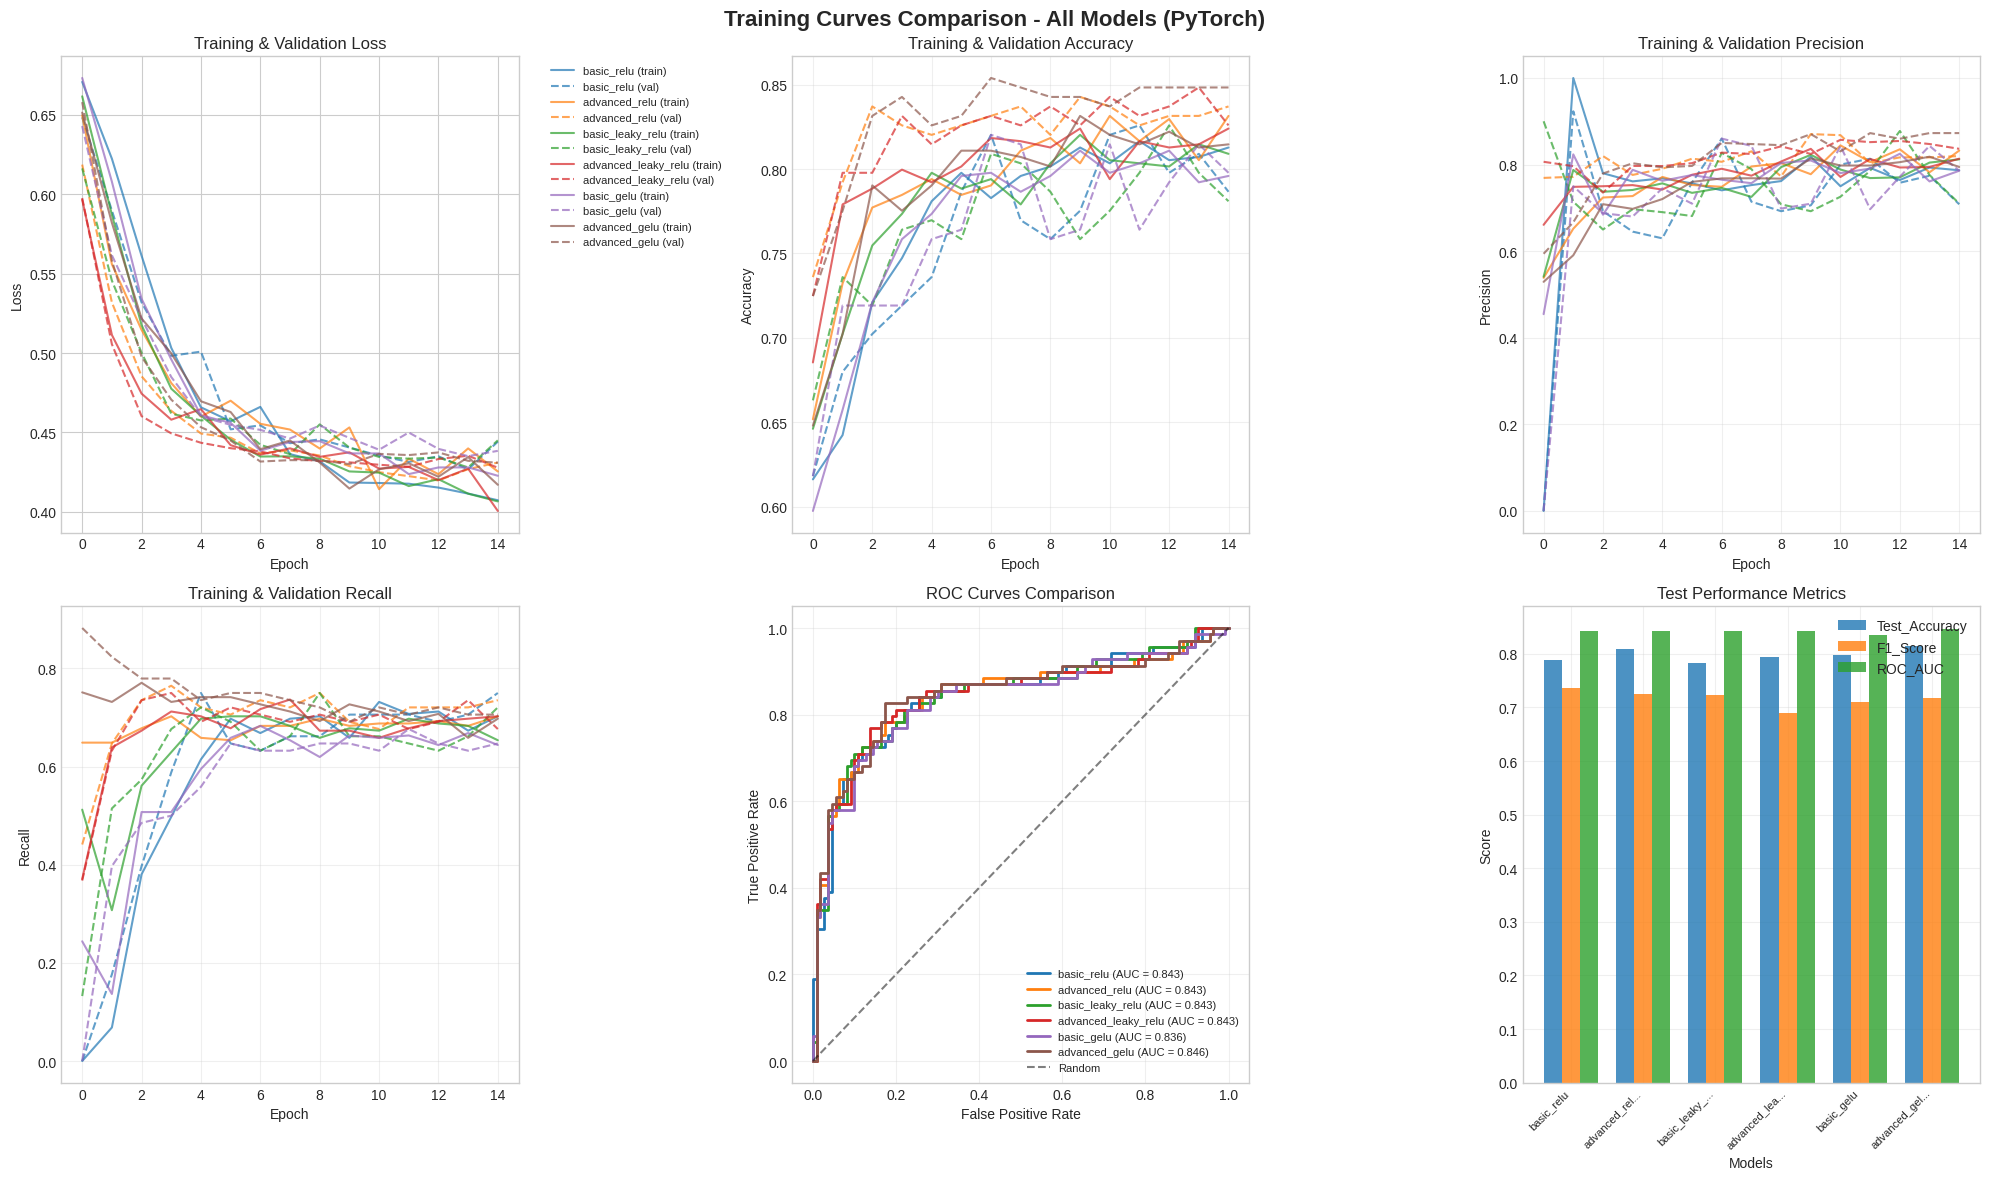

📊 Training curves visualization completed


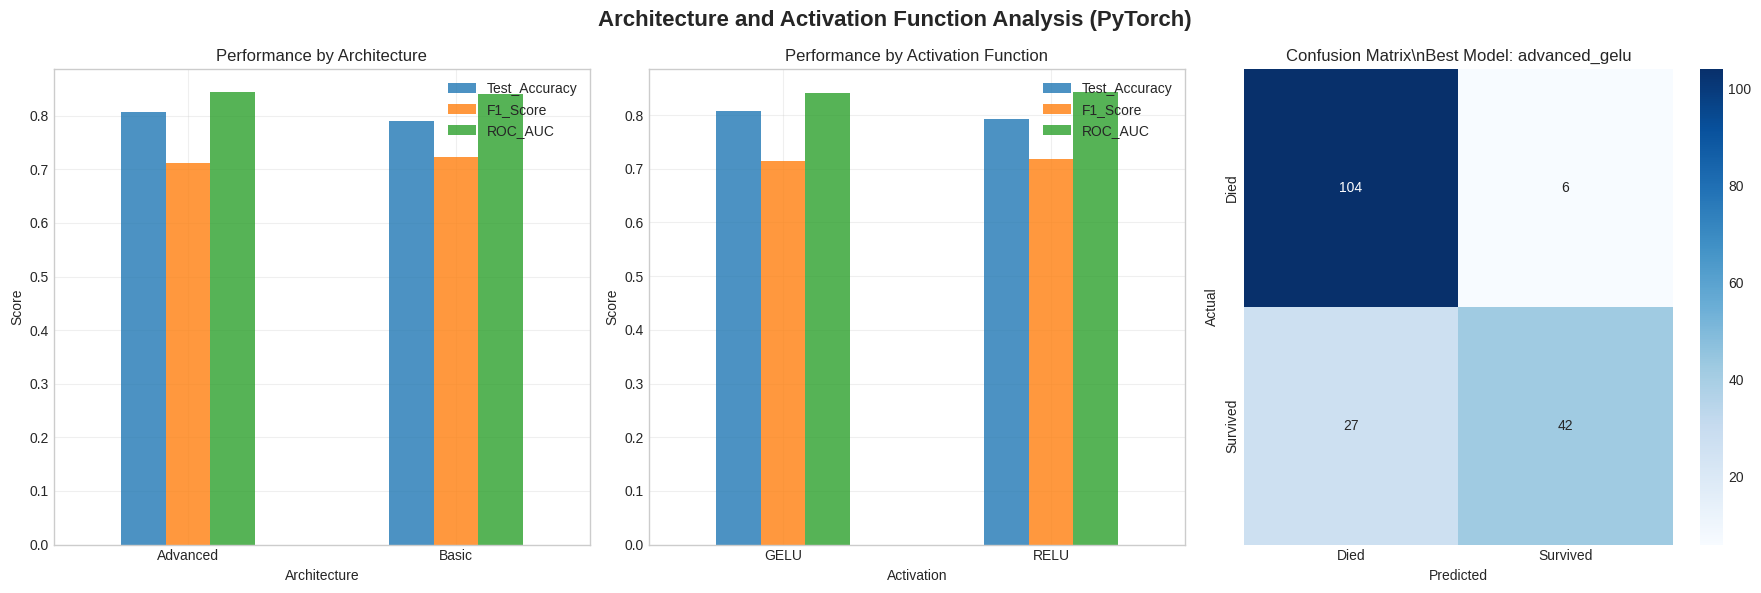

📈 Architecture and activation analysis completed

FINAL SUMMARY - PYTORCH IMPLEMENTATION

🏆 BEST PERFORMING MODEL:
   Model: advanced_gelu
   Architecture: Advanced
   Activation: GELU
   Test Accuracy: 0.8156
   F1-Score: 0.7179
   ROC-AUC: 0.8464

📊 KEY FINDINGS:
   • Best architecture: Advanced
   • Best activation: GELU
   • Average improvement (Advanced vs Basic): 0.0168

🔧 REGULARIZATION EFFECTIVENESS:
   • Basic models average: 0.7896
   • Advanced models average: 0.8063
   • Improvement: 2.12%

🆚 PYTORCH vs TENSORFLOW COMPARISON:
   • Framework: PyTorch (vs TensorFlow in original)
   • Model definition: Custom nn.Module classes (vs Sequential)
   • Training loop: Manual implementation (vs model.fit())
   • Data handling: DataLoader with TensorDataset (vs direct arrays)
   • Device management: Explicit GPU/CPU handling (vs automatic)
   • Metrics calculation: Manual implementation (vs built-in)

✅ Task 10 completed: All visualizations and analysis finished
🎉 ALL PYTORCH TASKS (5

In [11]:
# TASK 10: Plot Training Curves and Loss/Metrics Graphs
print("="*60)
print("TASK 10: TRAINING CURVES AND VISUALIZATION")
print("="*60)

# Set up plotting style
plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# 1. TRAINING CURVES FOR ALL MODELS
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Training Curves Comparison - All Models (PyTorch)', fontsize=16, fontweight='bold')

# Loss curves
axes[0, 0].set_title('Training & Validation Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')

# Accuracy curves
axes[0, 1].set_title('Training & Validation Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')

# Precision curves
axes[0, 2].set_title('Training & Validation Precision')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Precision')

# Recall curves
axes[1, 0].set_title('Training & Validation Recall')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Recall')

# Plot curves for each model
for i, (model_name, history) in enumerate(training_histories.items()):
    color = colors[i % len(colors)]

    # Loss
    axes[0, 0].plot(history['train_loss'], color=color, linestyle='-', alpha=0.7, label=f'{model_name} (train)')
    axes[0, 0].plot(history['val_loss'], color=color, linestyle='--', alpha=0.7, label=f'{model_name} (val)')

    # Accuracy
    axes[0, 1].plot(history['train_acc'], color=color, linestyle='-', alpha=0.7, label=f'{model_name} (train)')
    axes[0, 1].plot(history['val_acc'], color=color, linestyle='--', alpha=0.7, label=f'{model_name} (val)')

    # Precision
    axes[0, 2].plot(history['train_precision'], color=color, linestyle='-', alpha=0.7, label=f'{model_name} (train)')
    axes[0, 2].plot(history['val_precision'], color=color, linestyle='--', alpha=0.7, label=f'{model_name} (val)')

    # Recall
    axes[1, 0].plot(history['train_recall'], color=color, linestyle='-', alpha=0.7, label=f'{model_name} (train)')
    axes[1, 0].plot(history['val_recall'], color=color, linestyle='--', alpha=0.7, label=f'{model_name} (val)')

# Add legends (only to first subplot to avoid clutter)
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 2].grid(True, alpha=0.3)
axes[1, 0].grid(True, alpha=0.3)

# 2. ROC CURVES COMPARISON
axes[1, 1].set_title('ROC Curves Comparison')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')

for i, (model_name, results) in enumerate(evaluation_results.items()):
    fpr, tpr, _ = roc_curve(y_test, results['y_pred_proba'])
    auc_score = results['roc_auc']
    color = colors[i % len(colors)]
    axes[1, 1].plot(fpr, tpr, color=color, linewidth=2,
                    label=f'{model_name} (AUC = {auc_score:.3f})')

axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

# 3. PERFORMANCE METRICS COMPARISON
axes[1, 2].set_title('Test Performance Metrics')

metrics = ['Test_Accuracy', 'F1_Score', 'ROC_AUC']
x = np.arange(len(evaluation_results))
width = 0.25

for i, metric in enumerate(metrics):
    values = [evaluation_results[model]['test_accuracy'] if metric == 'Test_Accuracy'
              else evaluation_results[model]['f1_score'] if metric == 'F1_Score'
              else evaluation_results[model]['roc_auc'] for model in evaluation_results.keys()]

    axes[1, 2].bar(x + i*width, values, width, label=metric, alpha=0.8)

axes[1, 2].set_xlabel('Models')
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_xticks(x + width)
axes[1, 2].set_xticklabels([name[:12] + '...' if len(name) > 12 else name for name in evaluation_results.keys()],
                           rotation=45, ha='right', fontsize=8)
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Training curves visualization completed")

# 4. ARCHITECTURE & ACTIVATION COMPARISON
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Architecture and Activation Function Analysis (PyTorch)', fontsize=16, fontweight='bold')

# Architecture comparison
arch_data = comparison_df.groupby('Architecture')[['Test_Accuracy', 'F1_Score', 'ROC_AUC']].mean()
arch_data.plot(kind='bar', ax=axes[0], rot=0, alpha=0.8)
axes[0].set_title('Performance by Architecture')
axes[0].set_ylabel('Score')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Activation function comparison
activation_data = comparison_df.groupby('Activation')[['Test_Accuracy', 'F1_Score', 'ROC_AUC']].mean()
activation_data.plot(kind='bar', ax=axes[1], rot=0, alpha=0.8)
axes[1].set_title('Performance by Activation Function')
axes[1].set_ylabel('Score')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Best model confusion matrix heatmap
best_model_name = comparison_df.iloc[0]['Model']
best_results = evaluation_results[best_model_name]
cm = confusion_matrix(y_test, best_results['y_pred'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
axes[2].set_title(f'Confusion Matrix\\nBest Model: {best_model_name}')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print("📈 Architecture and activation analysis completed")

# 5. SUMMARY STATISTICS
print(f"\n{'='*70}")
print("FINAL SUMMARY - PYTORCH IMPLEMENTATION")
print(f"{'='*70}")

print(f"\n🏆 BEST PERFORMING MODEL:")
best_model = comparison_df.iloc[0]
print(f"   Model: {best_model['Model']}")
print(f"   Architecture: {best_model['Architecture']}")
print(f"   Activation: {best_model['Activation']}")
print(f"   Test Accuracy: {best_model['Test_Accuracy']:.4f}")
print(f"   F1-Score: {best_model['F1_Score']:.4f}")
print(f"   ROC-AUC: {best_model['ROC_AUC']:.4f}")

print(f"\n📊 KEY FINDINGS:")
print(f"   • Best architecture: {arch_data.idxmax()['Test_Accuracy']}")
print(f"   • Best activation: {activation_data.idxmax()['Test_Accuracy']}")
print(f"   • Average improvement (Advanced vs Basic): {(arch_data.loc['Advanced', 'Test_Accuracy'] - arch_data.loc['Basic', 'Test_Accuracy']):.4f}")

print(f"\n🔧 REGULARIZATION EFFECTIVENESS:")
basic_avg = comparison_df[comparison_df['Architecture'] == 'Basic']['Test_Accuracy'].mean()
advanced_avg = comparison_df[comparison_df['Architecture'] == 'Advanced']['Test_Accuracy'].mean()
print(f"   • Basic models average: {basic_avg:.4f}")
print(f"   • Advanced models average: {advanced_avg:.4f}")
print(f"   • Improvement: {((advanced_avg - basic_avg) / basic_avg * 100):.2f}%")

print(f"\n🆚 PYTORCH vs TENSORFLOW COMPARISON:")
print(f"   • Framework: PyTorch (vs TensorFlow in original)")
print(f"   • Model definition: Custom nn.Module classes (vs Sequential)")
print(f"   • Training loop: Manual implementation (vs model.fit())")
print(f"   • Data handling: DataLoader with TensorDataset (vs direct arrays)")
print(f"   • Device management: Explicit GPU/CPU handling (vs automatic)")
print(f"   • Metrics calculation: Manual implementation (vs built-in)")

print("\n✅ Task 10 completed: All visualizations and analysis finished")
print("🎉 ALL PYTORCH TASKS (5-10) COMPLETED SUCCESSFULLY!")
print("🔄 Successfully converted TensorFlow implementation to PyTorch!")